In [1]:
!pip -q install -U datasets transformers accelerate scikit-learn iterative-stratification psutil

print("Installation complete.")

from collections import Counter

from google.colab import drive
drive.mount('/content/drive')

# Load the dataset WITHOUT downloading it again
from datasets import load_from_disk

dataset = load_from_disk(
    "/content/drive/MyDrive/multieurlex_all_languages"
)

# Get the label feature from the training split
label_feature = dataset["train"].features["labels"].feature

# Count every label occurrence across all splits
for split in dataset:
    label_counts = Counter()

    for labels in dataset[split]["labels"]:
        label_counts.update(labels)

    print(f"\n{split.upper()}")
    print("Documents:", dataset[split].num_rows)
    print("Unique labels used:", len(label_counts))
    print("Total label assignments:", sum(label_counts.values()))

# Number of possible EUROVOC label classes
print("\nTotal possible label classes:", len(label_feature.names))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 148.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 176.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.0 MB/s eta 0:00:00
Installation complete.
Mounted at /content/drive

TRAIN
Documents: 55000
Unique labels used: 500
Total label assignments: 312244

TEST
Documents: 5000
Unique labels used: 465
Total label assignments: 32784

VALIDATION
Documents: 5000
Unique labels used: 454
Total label assignments: 31705

Total possible label classes: 567


In [2]:
import json
import pandas as pd # Needed for displaying Series later
import numpy as np # Needed for np.nan

baseline_metrics = {}
try:
    with open('/content/drive/MyDrive/baseline_metrics.json', 'r') as f:
        loaded_metrics = json.load(f)
        baseline_metrics.update(loaded_metrics) # Update the dict
    print("Baseline metrics loaded from '/content/drive/MyDrive/baseline_metrics.json'.")
except FileNotFoundError:
    print("baseline_metrics.json not found in Google Drive. Initializing empty metrics.")

# Ensure 'baseline_train_time' is present, even if as NaN
if 'baseline_train_time' not in baseline_metrics:
    baseline_metrics['baseline_train_time'] = np.nan
    print("Added 'baseline_train_time' as NaN to baseline_metrics.")

if baseline_metrics: # Only display if there's content
    print("Baseline Metrics:")
    display(pd.Series(baseline_metrics).round(4))

baseline_metrics.json not found in Google Drive. Initializing empty metrics.
Added 'baseline_train_time' as NaN to baseline_metrics.
Baseline Metrics:


,0
baseline_train_time,NaN


In [3]:
# @title
import os
import time
import random
import numpy as np
import pandas as pd
import torch
import json

from accelerate import Accelerator # Import Accelerator

# Initialize Accelerator for mixed precision and device management
# 'bf16' is suitable for TPUs/newer GPUs
accelerator = Accelerator(mixed_precision='no')
#f32


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- Main experiment controls ----
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
THRESHOLD = 0.50
N_TRAIN_PARTS = 10 # Number of chunks to divide the training data into

# Choose one:
#MODEL_NAME = "bert-base-multilingual-cased"   # mBERT
MODEL_NAME = "xlm-roberta-base"              # XLM-R

print("Model:", MODEL_NAME)

# Define checkpoint path
CHECKPOINT_PATH = "/content/drive/MyDrive/XLMR-Cyclic_MTM_checkpoint.pt"
TEMP_CHECKPOINT_PATH = "/content/drive/MyDrive/XLMR-Cyclic_MTM_checkpoint_tmp.pt"

# Initialize variables for checkpointing
start_epoch = 0
best_val_f1 = -np.inf
history = []

# Determine total training samples
total_training_samples = len(dataset["train"])

# Calculate total training steps and warmup steps
total_steps = (total_training_samples // BATCH_SIZE) * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)

print(f"Total training samples: {total_training_samples}")
print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

# # Load checkpoint if it exists

if os.path.exists(CHECKPOINT_PATH):
    print(f"\nCheckpoint found at {CHECKPOINT_PATH}. Loading state...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')

        start_epoch = checkpoint["epoch"]
        best_val_f1 = checkpoint["best_val_f1"]
        history = checkpoint["history"]

        # Model, optimizer, scheduler states are loaded later after they are initialized
        print(f"Resuming training from Epoch {start_epoch + 1}.")
    except Exception as e:
        print(f"Error loading checkpoint: {e}. Starting fresh.")
        # Reset to default if checkpoint is corrupted or unreadable
        start_epoch = 0
        best_val_f1 = -np.inf
        history = []
else:
    print("\nNo checkpoint found. Starting training from Epoch 1.")

Model: xlm-roberta-base
Total training samples: 55000
Total training steps: 34370
Warmup steps: 3437

No checkpoint found. Starting training from Epoch 1.


In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def multilabel_metrics(y_true, y_pred):
    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "exact_match": accuracy_score(y_true, y_pred)
    }

In [5]:
TEXT_COLUMN = "text"
LABEL_COLUMN = "labels"

In [6]:
# Build a consistent label vocabulary directly from the dataset's label feature.
# This assumes `label_feature` is already defined (e.g., from cell `l578f8uhvqEu`).

# Get the list of all possible label names (EUROVOC IDs as strings)
all_label_names_from_dataset = label_feature.names
NUM_LABELS = len(all_label_names_from_dataset)

# Create a simple 0-based index mapping for the multi-hot vector
# where the key is the label's integer ID from the dataset, and value is its index in our vector
label_to_index = {i: i for i in range(NUM_LABELS)}

print("Number of labels:", NUM_LABELS)
print("First mappings (dataset label ID -> internal vector index):", list(label_to_index.items())[:10])

Number of labels: 567
First mappings (dataset label ID -> internal vector index): [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9)]


In [7]:
def multi_hot(label_ids, mapping):
    vector = np.zeros(len(mapping), dtype=np.float32)
    for label_id in label_ids:
        vector[mapping[int(label_id)]] = 1.0
    return vector

In [8]:
from functools import partial
from transformers import AutoTokenizer # Ensure tokenizer is available
from datasets import concatenate_datasets

# Re-initialize tokenizer if it was deleted or for freshness
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# --- MANY-TO-MANY: deterministic per-epoch language rotation ---
LANGUAGES = ['bg', 'cs', 'da', 'de', 'el', 'en', 'es', 'et', 'fi', 'fr', 'hr',
             'hu', 'it', 'lt', 'lv', 'mt', 'nl', 'pl', 'pt', 'ro', 'sk', 'sl', 'sv']

# Small diverse subset (script + language-family variety) used for fast,
# multilingual per-epoch validation instead of English-only.
VAL_LANGUAGES = ["en", "de", "fr", "bg", "hu"]

def assign_language(idx, epoch):
    # Deterministic, reproducible: same (idx, epoch) always gives the same language.
    return LANGUAGES[(idx + epoch) % len(LANGUAGES)]

def preprocess_function_multilingual(examples, indices, tokenizer, label_to_index,
                                      max_length, offset=0, epoch=0, verbose=False):
    texts_to_tokenize = []
    langs_used = []
    for i, example in zip(indices, examples[TEXT_COLUMN]):
        lang = assign_language(i + offset, epoch)
        text = example.get(lang, "") or example.get("en", "")  # fallback to English if missing
        texts_to_tokenize.append(text)
        langs_used.append(lang)

    tokenized_inputs = tokenizer(
        texts_to_tokenize,
        truncation=True,
        max_length=max_length,
        padding=False # Do not pad here, pad dynamically in DataLoader
    )

    multi_hot_labels = [
        multi_hot(
            [lbl for lbl in row if int(lbl) in label_to_index],
            label_to_index
        )
        for row in examples[LABEL_COLUMN]
    ]
    tokenized_inputs["labels"] = multi_hot_labels

    if verbose:
        from collections import Counter
        counts = Counter(langs_used)
        print(f"    [Verify] epoch={epoch}, offset={offset}: language counts in this batch: "
              f"{dict(sorted(counts.items()))}")

    return tokenized_inputs

# --- Sanity check: confirm the rotation scheme is balanced and reproducible ---
def verify_rotation_scheme(train_split_size, languages, num_epochs):
    from collections import Counter
    print(f"Total training documents: {train_split_size}")
    print(f"Number of languages: {len(languages)}")
    print(f"Expected docs/language per epoch: ~{train_split_size / len(languages):.1f}\n")

    for epoch in [0, 1, num_epochs - 1]:
        counts = Counter(assign_language(i, epoch) for i in range(train_split_size))
        print(f"Epoch {epoch}: min={min(counts.values())}, max={max(counts.values())}")

    lang_e0 = assign_language(0, 0)
    lang_e1 = assign_language(0, 1)
    print(f"\nDoc 0: language epoch0='{lang_e0}', epoch1='{lang_e1}' "
          f"({'OK - different' if lang_e0 != lang_e1 else 'UNEXPECTED - same'})")

    c1, c2 = assign_language(1234, 3), assign_language(1234, 3)
    print(f"Reproducibility check: {c1} == {c2} -> {'OK' if c1 == c2 else 'MISMATCH (bug!)'}")

# --- Define training data chunking parameters ---
train_split_size = len(dataset["train"])
part_size = train_split_size // N_TRAIN_PARTS

print(f"\nTraining data will be processed in {N_TRAIN_PARTS} parts (approx {part_size} examples each).")
print(f"Total training samples for original dataset: {train_split_size}")

verify_rotation_scheme(train_split_size, LANGUAGES, NUM_EPOCHS)

# NOTE: preprocess_map_fn is no longer built once here for training -- it must be
# rebuilt fresh inside the training loop for each chunk/epoch, since language
# assignment depends on both `offset` (chunk start index) and `epoch`.
# See the training loop cell for where this is wired in.

# --- Validation: NOT tokenized here anymore. Per-epoch validation is now done
#     via evaluate_multilingual_full() directly on dataset["validation"] (raw),
#     across VAL_LANGUAGES, inside the training loop. No pre-tokenized val_loader. ---

# --- Test: kept English-only tokenized here ONLY for the legacy single-language
#     reporting cells further down (evaluate_model on test_loader, label-wise F1,
#     inference-time benchmark). The full 23-language test results come from the
#     separate per-language / pooled evaluation cells near the end of the notebook. ---
english_preprocess_fn = partial(
    lambda examples, tokenizer, label_to_index, max_length: {
        **tokenizer(
            [ex.get('en', '') for ex in examples[TEXT_COLUMN]],
            truncation=True, max_length=max_length, padding=False
        ),
        "labels": [
            multi_hot([lbl for lbl in row if int(lbl) in label_to_index], label_to_index)
            for row in examples[LABEL_COLUMN]
        ]
    },
    tokenizer=tokenizer, label_to_index=label_to_index, max_length=MAX_LENGTH
)

print("\nProcessing test data (English, for legacy single-language reporting cells)...")
tokenized_test = dataset["test"].map(
    english_preprocess_fn,
    batched=True,
    remove_columns=[TEXT_COLUMN, LABEL_COLUMN],
    load_from_cache_file=False
)
print(f"Tokenized test data size: {len(tokenized_test)}")

tokenized_dataset = {
    "train": dataset["train"], # raw; tokenized per-chunk during training with language rotation
    "test": tokenized_test     # English-only, for legacy cells
}

print("\nTokenized dataset features (test split):")
print(tokenized_dataset["test"].column_names)


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]


Training data will be processed in 10 parts (approx 5500 examples each).
Total training samples for original dataset: 55000
Total training documents: 55000
Number of languages: 23
Expected docs/language per epoch: ~2391.3

Epoch 0: min=2391, max=2392
Epoch 1: min=2391, max=2392
Epoch 9: min=2391, max=2392

Doc 0: language epoch0='bg', epoch1='cs' (OK - different)
Reproducibility check: pt == pt -> OK

Processing test data (English, for legacy single-language reporting cells)...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenized test data size: 5000

Tokenized dataset features (test split):
['celex_id', 'labels', 'input_ids', 'attention_mask']


### Streamlined for mBERT Training

This section previously discussed freeing up RAM after TF-IDF training and saving baseline metrics. With the current notebook setup, TF-IDF related objects are no longer created, and baseline metrics are loaded at the start to ensure a clean environment for mBERT training.

### Streamlined mBERT Workflow

This section previously provided instructions for manually running only the mBERT model. The notebook has now been streamlined to automatically proceed with mBERT preprocessing and training. After a runtime restart, you can execute all cells sequentially, skipping any explicitly marked 'removed' cells.

### Removed: Empty Cell

This cell was previously empty and has been removed to streamline the notebook for mBERT training.

In [9]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

# Data collator will dynamically pad the batches
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

# Remove 'celex_id' column as it's not needed for model input
test_dataset_for_loader = tokenized_dataset["test"].remove_columns(["celex_id"])

# Test DataLoader (English-only, used by legacy single-language reporting cells)
test_loader = DataLoader(
    test_dataset_for_loader,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

print("Test DataLoader created. (Validation is now evaluated via evaluate_multilingual_full, no val_loader.)")

# Example batch check
batch = next(iter(test_loader))
for k, v in batch.items():
    print(k, v.shape, v.dtype)


Test DataLoader created. (Validation is now evaluated via evaluate_multilingual_full, no val_loader.)
labels torch.Size([16, 567]) torch.int64
input_ids torch.Size([16, 256]) torch.int64
attention_mask torch.Size([16, 256]) torch.int64


In [10]:
from transformers import AutoConfig, AutoModelForSequenceClassification

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

# model.to(device) # Accelerator handles device placement

print("Model:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: xlm-roberta-base
Number of labels: 567


In [11]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

# Initialize optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Prepare model, optimizer, test_loader, scheduler, and data_collator with Accelerator
# (val_loader no longer exists -- validation now runs via evaluate_multilingual_full)
model, optimizer, test_loader, scheduler, data_collator = accelerator.prepare(
    model, optimizer, test_loader, scheduler, data_collator
)

_sample_param_name, _sample_param = next(iter(accelerator.unwrap_model(model).named_parameters()))
print(f"[Diagnostic] Sample parameter '{_sample_param_name}' dtype: {_sample_param.dtype}")

# Load states if resuming from a checkpoint (start_epoch > 0)
if start_epoch > 0:
    accelerator.unwrap_model(model).load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    print(f"Model, Optimizer, and Scheduler states loaded successfully for resuming from epoch {start_epoch + 1}.")

print("Training steps:", total_steps)
print("Warmup steps:", warmup_steps)


[Diagnostic] Sample parameter 'classifier.dense.weight' dtype: torch.float32
Training steps: 34370
Warmup steps: 3437


In [12]:
import numpy as np
from tqdm.auto import tqdm
from scipy.special import expit # Explicitly import expit

def evaluate_model(model, loader, threshold=0.5):
    # Legacy English-only evaluator, used for the test_loader-based reporting cells.
    unwrapped_model = accelerator.unwrap_model(model)
    unwrapped_model.eval()

    all_logits = []
    all_labels = []
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            batch["labels"] = batch["labels"].to(torch.float32)
            outputs = unwrapped_model(**batch)

            total_loss += outputs.loss.item()
            n_batches += 1

            all_logits.append(outputs.logits.detach().cpu())
            all_labels.append(batch["labels"].detach().cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()

    probabilities = expit(logits)
    predictions = (probabilities >= threshold).astype(int)

    metrics = multilabel_metrics(labels, predictions)
    metrics["loss"] = total_loss / max(n_batches, 1)

    return metrics, probabilities, predictions, labels


# --- NEW: multilingual evaluator, used for per-epoch validation (VAL_LANGUAGES)
#     and the final full 23-language test. Computes loss manually (BCEWithLogitsLoss)
#     so val_loss tracking still works even though this bypasses the model's
#     internal .loss (which requires a DataLoader/collator, not raw per-language text). ---
def evaluate_multilingual_full(model, tokenizer, raw_dataset, label_to_index,
                                 num_labels, languages, batch_size=16, max_length=256,
                                 compute_loss=True):
    model.eval()
    probs_by_lang, true_by_lang = {}, {}
    total_loss = 0.0
    n_batches = 0
    loss_fn = torch.nn.BCEWithLogitsLoss() if compute_loss else None

    for lang in tqdm(languages, desc="Languages", leave=False):
        texts, label_rows = [], []
        for row in raw_dataset:
            text = row["text"].get(lang)
            if text:
                texts.append(text)
                mh = np.zeros(num_labels, dtype=np.float32)
                for l in row["labels"]:
                    if l in label_to_index:
                        mh[label_to_index[l]] = 1.0
                label_rows.append(mh)
        if not texts:
            continue

        logits_list = []
        n_batches_lang = (len(texts) + batch_size - 1) // batch_size
        for i in tqdm(range(0, len(texts), batch_size), total=n_batches_lang, desc=f"  {lang}", leave=False):
            batch_texts = texts[i:i+batch_size]
            batch_labels = np.stack(label_rows[i:i+batch_size])
            enc = tokenizer(batch_texts, truncation=True, padding=True,
                             max_length=max_length, return_tensors="pt").to(accelerator.device)
            with torch.no_grad():
                out = model(**enc)
            logits_list.append(out.logits.cpu())

            if compute_loss:
                labels_t = torch.tensor(batch_labels, dtype=torch.float32)
                total_loss += loss_fn(out.logits.cpu(), labels_t).item()
                n_batches += 1

        probs_by_lang[lang] = torch.sigmoid(torch.cat(logits_list)).numpy()
        true_by_lang[lang] = np.stack(label_rows)

    avg_loss = total_loss / max(n_batches, 1) if compute_loss else None
    return probs_by_lang, true_by_lang, avg_loss


### Removed: Empty Cell

This cell was previously empty and has been removed to streamline the notebook for mBERT training.

In [13]:
import numpy as np
import time
from tqdm.auto import tqdm
import gc # For garbage collection
import torch.cuda # Import for clearing cuda cache

# History and best_val_f1 are initialized earlier and loaded from checkpoint if resuming

training_start = time.perf_counter()

print(f"Total training samples: {total_training_samples}")
print(f"Total steps for scheduler: {total_steps}")
print(f"Warmup steps for scheduler: {warmup_steps}")
print(f"Starting training from epoch {start_epoch + 1} for {NUM_EPOCHS - start_epoch} epochs.")

train_split_size = len(tokenized_dataset["train"]) # raw dataset["train"]
part_size = train_split_size // N_TRAIN_PARTS

# Loop through epochs, starting from start_epoch if resuming
for epoch in tqdm(range(start_epoch, NUM_EPOCHS), desc="Epochs", initial=start_epoch, total=NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    current_step_in_epoch = 0

    epoch_start = time.perf_counter()

    for part_idx in range(N_TRAIN_PARTS):
        start_idx = part_idx * part_size
        end_idx = (part_idx + 1) * part_size if part_idx < N_TRAIN_PARTS - 1 else train_split_size

        print(f"  Epoch {epoch+1}/{NUM_EPOCHS}: Tokenizing and training on part {part_idx+1}/{N_TRAIN_PARTS} "
              f"(indices {start_idx} to {end_idx-1})...")

        raw_train_part = tokenized_dataset["train"].select(range(start_idx, end_idx))

        # --- MANY-TO-MANY: rebuild the map fn for THIS chunk + THIS epoch ---
        chunk_preprocess_fn = partial(
            preprocess_function_multilingual,
            tokenizer=tokenizer,
            label_to_index=label_to_index,
            max_length=MAX_LENGTH,
            offset=start_idx,
            epoch=epoch,
            verbose=(part_idx == 0)  # print a language-count sample once per epoch, first chunk only
        )

        tokenized_part = raw_train_part.map(
            chunk_preprocess_fn,
            batched=True,
            with_indices=True,  # REQUIRED: passes row indices into preprocess_function_multilingual
            remove_columns=[TEXT_COLUMN, LABEL_COLUMN, "celex_id"],
            load_from_cache_file=False
        )

        # NOTE: shuffle=False -- keeps batch order fully deterministic/reproducible,
        # matching the deterministic language-rotation scheme. Language assignment
        # itself is unaffected by this either way (it's fixed during .map() above).
        train_loader_part = DataLoader(
            tokenized_part,
            batch_size=BATCH_SIZE,
            shuffle=False,
            collate_fn=data_collator
        )

        prepared_train_loader_part = accelerator.prepare(train_loader_part)

        for batch_idx, batch in enumerate(tqdm(prepared_train_loader_part,
                                                 desc=f"Training part {part_idx+1}/{N_TRAIN_PARTS}", leave=False)):
            optimizer.zero_grad()
            batch["labels"] = batch["labels"].to(torch.float32)

            outputs = model(**batch)
            loss = outputs.loss

            accelerator.backward(loss)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            current_step_in_epoch += 1

        del raw_train_part
        del tokenized_part
        del train_loader_part
        del prepared_train_loader_part
        torch.cuda.empty_cache()
        gc.collect()
        print(f"  Memory freed after part {part_idx+1}.")

    train_loss = running_loss / max(current_step_in_epoch, 1)

    # --- Multilingual per-epoch validation (VAL_LANGUAGES subset, for speed) ---
    val_probs_by_lang, val_true_by_lang, val_loss = evaluate_multilingual_full(
        accelerator.unwrap_model(model), tokenizer, dataset["validation"],
        label_to_index, NUM_LABELS, VAL_LANGUAGES, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
    )
    val_pooled_probs = np.concatenate(list(val_probs_by_lang.values()))
    val_pooled_true = np.concatenate(list(val_true_by_lang.values()))
    val_pooled_preds = (val_pooled_probs >= THRESHOLD).astype(int)
    val_metrics = multilabel_metrics(val_pooled_true, val_pooled_preds)
    val_metrics["loss"] = val_loss

    epoch_time = time.perf_counter() - epoch_start
    current_lr = scheduler.get_last_lr()[0]
    print(f"[Diagnostic] LR at end of epoch {epoch+1}: {current_lr:.3e}")
    record = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_micro_f1": val_metrics["micro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "epoch_time_sec": epoch_time,
        "val_languages": VAL_LANGUAGES
    }
    history.append(record)

    current_val_macro_f1 = val_metrics["macro_f1"]
    if current_val_macro_f1 > best_val_f1:
        best_val_f1 = current_val_macro_f1

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train loss={train_loss:.10f} | "
        f"val loss={val_metrics['loss']:.10f} | "
        f"val micro-F1={val_metrics['micro_f1']:.10f} | "
        f"val macro-F1={val_metrics['macro_f1']:.10f} | "
        f"time={epoch_time:.1f}s"
    )

    # --- Checkpoint Saving Logic (Atomic Save) ---
    checkpoint_to_save = {
        "epoch": epoch + 1,
        "model_state_dict": accelerator.unwrap_model(model).state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_f1": best_val_f1,
        "history": history,
        # Extra config metadata, so a resumed/reloaded checkpoint is self-describing:
        "languages_used": LANGUAGES,
        "val_languages": VAL_LANGUAGES,
        "num_train_parts": N_TRAIN_PARTS,
        "max_length": MAX_LENGTH,
        "model_name": MODEL_NAME,
    }
    accelerator.save(checkpoint_to_save, TEMP_CHECKPOINT_PATH)
    os.replace(TEMP_CHECKPOINT_PATH, CHECKPOINT_PATH)
    print(f"Checkpoint saved to {CHECKPOINT_PATH} after epoch {epoch+1}.")

total_training_time = time.perf_counter() - training_start

print(f"Total Transformer training time: {total_training_time/60:.2f} minutes")


Total training samples: 55000
Total steps for scheduler: 34370
Warmup steps for scheduler: 3437
Starting training from epoch 1 for 10 epochs.


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/10: Tokenizing and training on part 1/10 (indices 0 to 5499)...


Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

    [Verify] epoch=0, offset=0: language counts in this batch: {'bg': 44, 'cs': 44, 'da': 44, 'de': 44, 'el': 44, 'en': 44, 'es': 44, 'et': 44, 'fi': 44, 'fr': 44, 'hr': 44, 'hu': 43, 'it': 43, 'lt': 43, 'lv': 43, 'mt': 43, 'nl': 43, 'pl': 43, 'pt': 43, 'ro': 43, 'sk': 43, 'sl': 43, 'sv': 43}
    [Verify] epoch=0, offset=0: language counts in this batch: {'bg': 43, 'cs': 43, 'da': 43, 'de': 43, 'el': 43, 'en': 43, 'es': 43, 'et': 43, 'fi': 43, 'fr': 43, 'hr': 43, 'hu': 44, 'it': 44, 'lt': 44, 'lv': 44, 'mt': 44, 'nl': 44, 'pl': 44, 'pt': 44, 'ro': 44, 'sk': 44, 'sl': 44, 'sv': 43}
    [Verify] epoch=0, offset=0: language counts in this batch: {'bg': 44, 'cs': 44, 'da': 44, 'de': 44, 'el': 44, 'en': 44, 'es': 44, 'et': 44, 'fi': 44, 'fr': 44, 'hr': 43, 'hu': 43, 'it': 43, 'lt': 43, 'lv': 43, 'mt': 43, 'nl': 43, 'pl': 43, 'pt': 43, 'ro': 43, 'sk': 43, 'sl': 43, 'sv': 44}
    [Verify] epoch=0, offset=0: language counts in this batch: {'bg': 43, 'cs': 43, 'da': 43, 'de': 43, 'el': 43, 'en'

...

  bg:   0%|          | 0/313 [00:00<?, ?it/s]

  hu:   0%|          | 0/313 [00:00<?, ?it/s]

[Diagnostic] LR at end of epoch 9: 2.205e-06
Epoch 9/10 | train loss=0.0197985911 | val loss=0.0238672156 | val micro-F1=0.6260836329 | val macro-F1=0.1120718756 | time=1702.9s
Checkpoint saved to /content/drive/MyDrive/XLMR-Cyclic_MTM_checkpoint.pt after epoch 9.
  Epoch 10/10: Tokenizing and training on part 1/10 (indices 0 to 5499)...


Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

KeyboardInterrupt: 

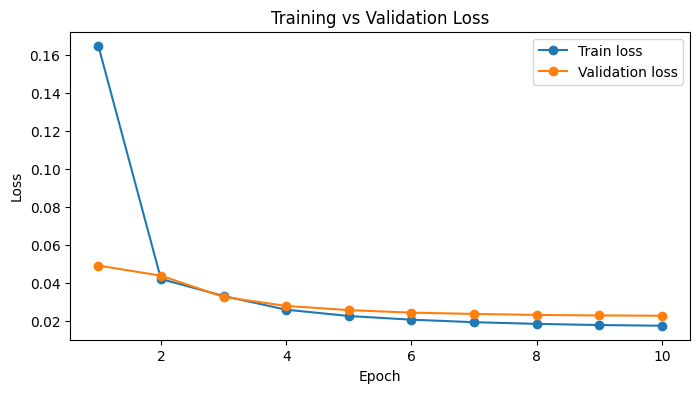

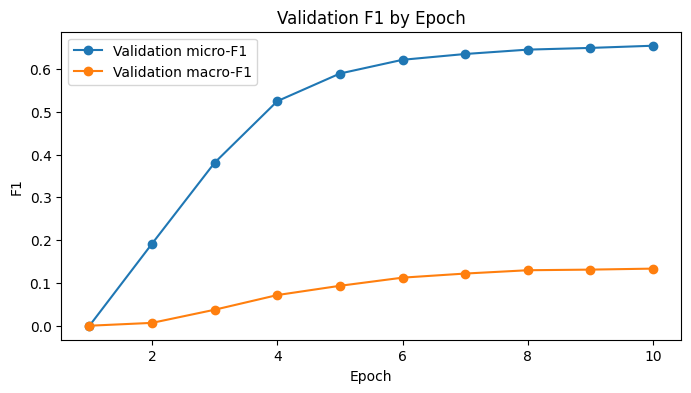

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Import pandas

# Convert history list of dicts to a DataFrame for easier plotting
history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["val_micro_f1"], marker="o", label="Validation micro-F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation macro-F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Validation F1 by Epoch")
plt.legend()
plt.show()

In [ ]:
transformer_metrics, test_probabilities, transformer_pred, test_labels = evaluate_model(
    model,
    test_loader,
    threshold=THRESHOLD
)

print("Transformer test metrics:")
display(pd.Series(transformer_metrics).round(4))


Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Transformer test metrics:


,0
micro_f1,0.5926
macro_f1,0.1201
micro_precision,0.8610
macro_precision,0.1816
micro_recall,0.4517
macro_recall,0.1028
exact_match,0.0130
loss,0.0260


In [ ]:
import numpy as np # Ensure numpy is available for np.nan

comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Micro-F1": baseline_metrics.get("micro_f1", np.nan),
        "Macro-F1": baseline_metrics.get("macro_f1", np.nan),
        "Micro-Precision": baseline_metrics.get("micro_precision", np.nan),
        "Micro-Recall": baseline_metrics.get("micro_recall", np.nan),
        "Exact-Match": baseline_metrics.get("exact_match", np.nan),
        "Training time (sec)": baseline_metrics.get("baseline_train_time", np.nan)
    },
    {
        "Model": MODEL_NAME,
        "Micro-F1": transformer_metrics["micro_f1"],
        "Macro-F1": transformer_metrics["macro_f1"],
        "Micro-Precision": transformer_metrics["micro_precision"],
        "Micro-Recall": transformer_metrics["micro_recall"],
        "Exact-Match": transformer_metrics["exact_match"],
        "Training time (sec)": total_training_time
    }
])

display(comparison.round(4))


,Model,Micro-F1,Macro-F1,Micro-Precision,Micro-Recall,Exact-Match,Training time (sec)
0,TF-IDF + Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN
1,bert-base-multilingual-cased,0.5926,0.1201,0.861,0.4517,0.013,12664.8849


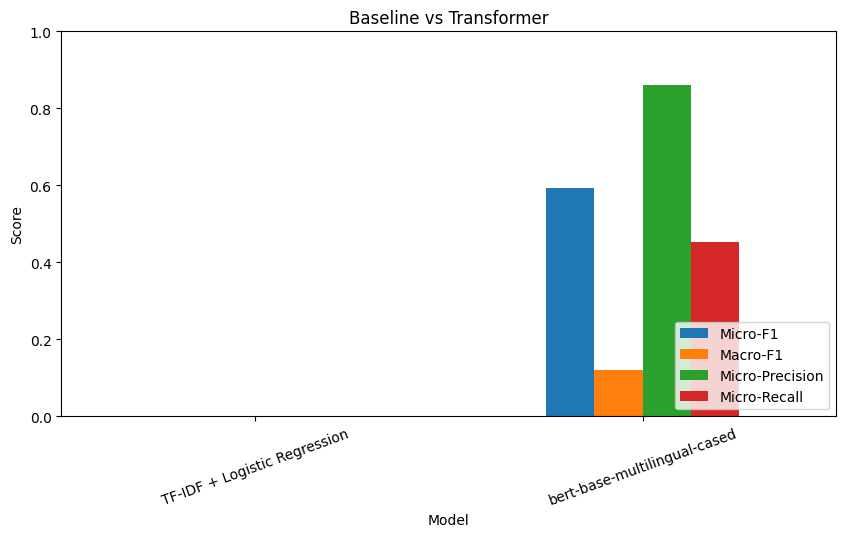

In [ ]:
metric_cols = ["Micro-F1", "Macro-F1", "Micro-Precision", "Micro-Recall"]

comparison.set_index("Model")[metric_cols].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1)
)

plt.ylabel("Score")
plt.title("Baseline vs Transformer")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()


In [ ]:
threshold_results = []

for threshold in [0.05, 0.30, 0.40, 0.50, 0.60, 0.70]:
    pred = (test_probabilities >= threshold).astype(int)

    m = multilabel_metrics(test_labels, pred)

    threshold_results.append({
        "threshold": threshold,
        "micro_f1": m["micro_f1"],
        "macro_f1": m["macro_f1"],
        "micro_precision": m["micro_precision"],
        "micro_recall": m["micro_recall"]
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(4))


,threshold,micro_f1,macro_f1,micro_precision,micro_recall
0,0.05,0.4229,0.1591,0.2910,0.7737
1,0.30,0.6298,0.1515,0.7472,0.5442
2,0.40,0.6157,0.1352,0.8166,0.4941
3,0.50,0.5926,0.1201,0.8610,0.4517
4,0.60,0.5625,0.1057,0.9010,0.4089
5,0.70,0.5085,0.0873,0.9337,0.3494


In [ ]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

results = []

for threshold in thresholds:
    metrics, _, _, _ = evaluate_model(
        model,
        test_loader,
        threshold=threshold
    )

    results.append({
        "threshold": threshold,
        **metrics
    })

threshold_results = pd.DataFrame(results)

display(threshold_results.round(4))

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

,threshold,micro_f1,macro_f1,micro_precision,macro_precision,micro_recall,macro_recall,exact_match,loss
0,0.05,0.4229,0.1591,0.2910,0.1293,0.7737,0.3103,0.0000,0.026
1,0.10,0.5499,0.1791,0.4537,0.1834,0.6978,0.2381,0.0020,0.026
2,0.15,0.5996,0.1775,0.5601,0.1959,0.6451,0.1994,0.0030,0.026
3,0.20,0.6217,0.1679,0.6396,0.1978,0.6049,0.1727,0.0046,0.026
4,0.25,0.6297,0.1586,0.6992,0.1980,0.5728,0.1544,0.0092,0.026
5,0.30,0.6298,0.1515,0.7472,0.2029,0.5442,0.1416,0.0150,0.026
6,0.35,0.6243,0.1424,0.7865,0.1969,0.5176,0.1296,0.0154,0.026
7,0.40,0.6157,0.1352,0.8166,0.1936,0.4941,0.1207,0.0148,0.026
8,0.45,0.6053,0.1275,0.8414,0.1860,0.4727,0.1112,0.0144,0.026
9,0.50,0.5926,0.1201,0.8610,0.1816,0.4517,0.1028,0.0130,0.026


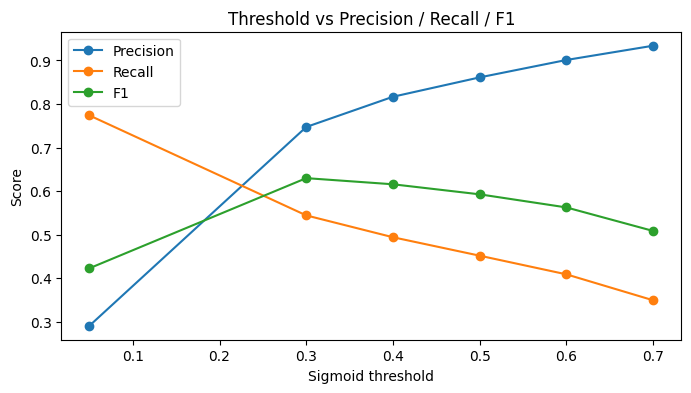

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["micro_precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["micro_recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["micro_f1"], marker="o", label="F1")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")
plt.legend()
plt.show()


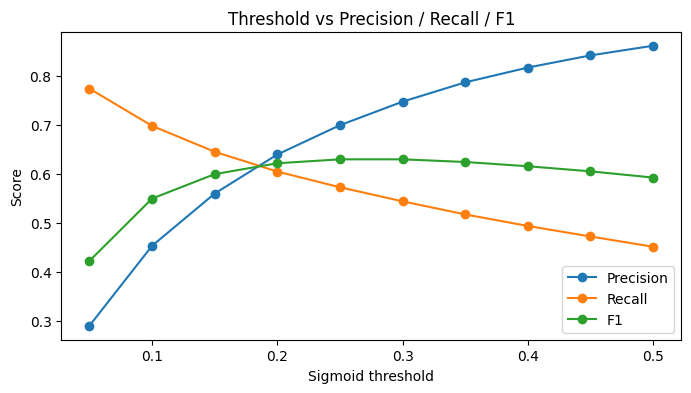

In [ ]:
threshold_df = threshold_results  # alias, so the plotting code works as-is
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["micro_precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["micro_recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["micro_f1"], marker="o", label="F1")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")
plt.legend()
plt.show()



Languages:   0%|          | 0/23 [00:00<?, ?it/s]

  bg:   0%|          | 0/313 [00:00<?, ?it/s]

  bg: n=5000 done.


  cs:   0%|          | 0/313 [00:00<?, ?it/s]

  cs: n=5000 done.


...

,0
micro_precision,0.8507
micro_recall,0.4384
micro_f1,0.5786
macro_precision,0.1995
macro_recall,0.0987
macro_f1,0.1164
exact_match,0.0151



=== Overall metrics — AVERAGED across the 23 per-language scores (threshold = 0.5) ===


,0
micro_precision,0.8506
micro_recall,0.4384
micro_f1,0.5785
macro_precision,0.1780
macro_recall,0.0987
macro_f1,0.1160



=== Threshold sweep (pooled across all 23 languages) ===


,threshold,micro_precision,micro_recall,micro_f1,macro_f1
0,0.05,0.2812,0.7640,0.4111,0.1482
1,0.10,0.4343,0.6846,0.5315,0.1669
2,0.15,0.5412,0.6319,0.5830,0.1654
3,0.20,0.6214,0.5926,0.6066,0.1587
4,0.25,0.6825,0.5604,0.6154,0.1512
5,0.30,0.7306,0.5318,0.6155,0.1440
6,0.35,0.7704,0.5060,0.6108,0.1370
7,0.40,0.8018,0.4818,0.6019,0.1297
8,0.45,0.8278,0.4596,0.5911,0.1231
9,0.50,0.8507,0.4384,0.5786,0.1164


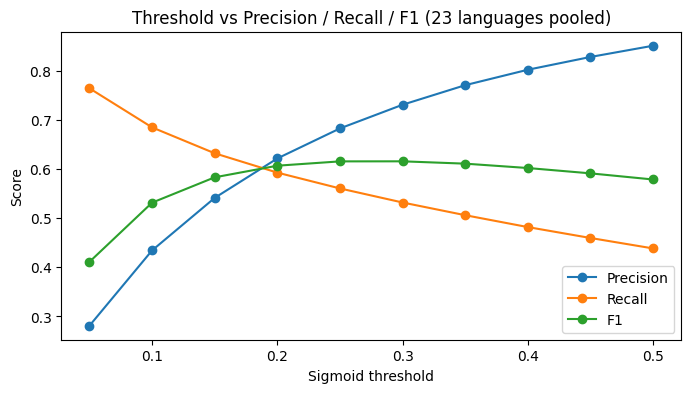

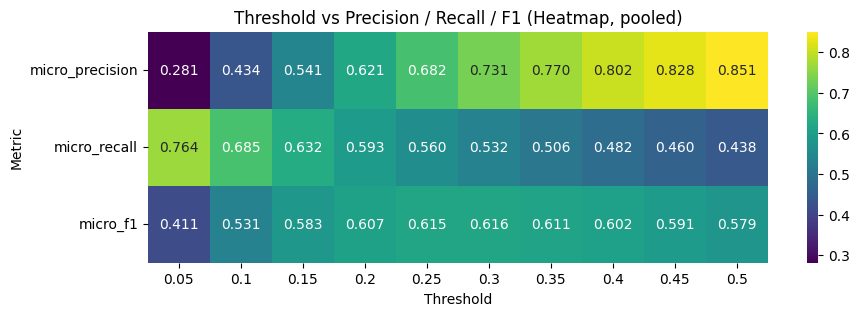

In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import torch
import pandas as pd
import seaborn as sns


LANGUAGES = ['bg', 'cs', 'da', 'de', 'el', 'en', 'es', 'et', 'fi', 'fr', 'hr',
             'hu', 'it', 'lt', 'lv', 'mt', 'nl', 'pl', 'pt', 'ro', 'sk', 'sl', 'sv']

# ============================================================
# STEP 1 — Run inference ONCE across all 23 languages
# Produces raw probabilities + true labels per language.
# Everything else below is derived from this without re-running the model.
# ============================================================

def evaluate_multilingual_full(model, tokenizer, raw_dataset, label_to_index,
                                 num_labels, languages, batch_size=16, max_length=256):
    model.eval()
    probs_by_lang, true_by_lang = {}, {}

    for lang in tqdm(languages, desc="Languages"):
        texts, label_rows = [], []
        for row in raw_dataset:
            text = row["text"].get(lang)
            if text:
                texts.append(text)
                mh = np.zeros(num_labels, dtype=np.float32)
                for l in row["labels"]:
                    if l in label_to_index:
                        mh[label_to_index[l]] = 1.0
                label_rows.append(mh)
        if not texts:
            tqdm.write(f"  Skipping {lang}: no documents found.")
            continue

        logits_list = []
        n_batches = (len(texts) + batch_size - 1) // batch_size
        for i in tqdm(range(0, len(texts), batch_size), total=n_batches, desc=f"  {lang}", leave=False):
            enc = tokenizer(texts[i:i+batch_size], truncation=True, padding=True,
                             max_length=max_length, return_tensors="pt").to(accelerator.device)
            with torch.no_grad():
                out = model(**enc)
            logits_list.append(out.logits.cpu())

        probs_by_lang[lang] = torch.sigmoid(torch.cat(logits_list)).numpy()
        true_by_lang[lang] = np.stack(label_rows)
        tqdm.write(f"  {lang}: n={len(texts)} done.")

    return probs_by_lang, true_by_lang


# Run it (replace `model`, `tokenizer`, `dataset["test"]`, `label_to_index`, `NUM_LABELS`
# with your actual variables)
probs_by_lang, true_by_lang = evaluate_multilingual_full(
    accelerator.unwrap_model(model), tokenizer, dataset["test"],
    label_to_index, NUM_LABELS, LANGUAGES
)

# Save immediately so you never lose this even if the model/session is gone later
np.savez(
    "/content/drive/MyDrive/XLMR_MTM_eval_probs_by_lang.npz",
    **{f"{l}_probs": probs_by_lang[l] for l in probs_by_lang},
    **{f"{l}_true": true_by_lang[l] for l in true_by_lang}
)
print("Saved raw probabilities + labels to Drive.\n")


# ============================================================
# STEP 2 — Per-language metrics (fixed threshold = 0.5)
# ============================================================

def build_per_lang_df(probs_by_lang, true_by_lang, threshold=0.5):
    results = []
    for lang, probs in probs_by_lang.items():
        preds = (probs >= threshold).astype(int)
        y_true = true_by_lang[lang]
        results.append({
            "language": lang,
            "n_examples": len(probs),
            "micro_precision": precision_score(y_true, preds, average="micro", zero_division=0),
            "micro_recall": recall_score(y_true, preds, average="micro", zero_division=0),
            "micro_f1": f1_score(y_true, preds, average="micro", zero_division=0),
            "macro_precision": precision_score(y_true, preds, average="macro", zero_division=0),
            "macro_recall": recall_score(y_true, preds, average="macro", zero_division=0),
            "macro_f1": f1_score(y_true, preds, average="macro", zero_division=0),
        })
    return pd.DataFrame(results)

per_lang_df = build_per_lang_df(probs_by_lang, true_by_lang, threshold=0.5)
print("=== Per-language metrics (threshold = 0.5) ===")
display(per_lang_df.round(4))


# ============================================================
# STEP 3 — Overall metrics: POOLED and AVERAGED
# ============================================================

pooled_probs = np.concatenate(list(probs_by_lang.values()))
pooled_true = np.concatenate(list(true_by_lang.values()))
pooled_preds = (pooled_probs >= 0.5).astype(int)

pooled_overall = {
    "micro_precision": precision_score(pooled_true, pooled_preds, average="micro", zero_division=0),
    "micro_recall": recall_score(pooled_true, pooled_preds, average="micro", zero_division=0),
    "micro_f1": f1_score(pooled_true, pooled_preds, average="micro", zero_division=0),
    "macro_precision": precision_score(pooled_true, pooled_preds, average="macro", zero_division=0),
    "macro_recall": recall_score(pooled_true, pooled_preds, average="macro", zero_division=0),
    "macro_f1": f1_score(pooled_true, pooled_preds, average="macro", zero_division=0),
    "exact_match": accuracy_score(pooled_true, pooled_preds),
}

print("\n=== Overall metrics — POOLED across all 23 languages (threshold = 0.5) ===")
display(pd.Series(pooled_overall).round(4))

overall_avg = per_lang_df[[
    "micro_precision", "micro_recall", "micro_f1",
    "macro_precision", "macro_recall", "macro_f1"
]].mean()

print("\n=== Overall metrics — AVERAGED across the 23 per-language scores (threshold = 0.5) ===")
display(overall_avg.round(4))


# ============================================================
# STEP 4 — Threshold sweep (pooled across all 23 languages)
# ============================================================

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

for t in thresholds:
    preds = (pooled_probs >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "micro_precision": precision_score(pooled_true, preds, average="micro", zero_division=0),
        "micro_recall": recall_score(pooled_true, preds, average="micro", zero_division=0),
        "micro_f1": f1_score(pooled_true, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(pooled_true, preds, average="macro", zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n=== Threshold sweep (pooled across all 23 languages) ===")
display(threshold_df.round(4))

# --- Plots ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["micro_precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["micro_recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["micro_f1"], marker="o", label="F1")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1 (23 languages pooled)")
plt.legend()
plt.show()

heatmap_data = threshold_df.set_index("threshold")[["micro_precision", "micro_recall", "micro_f1"]].T
plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Threshold vs Precision / Recall / F1 (Heatmap, pooled)")
plt.show()

In [ ]:
# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

if torch.cuda.is_available():
    print(f"Peak GPU memory: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")


Total parameters: 178,289,463
Trainable parameters: 178,289,463


In [ ]:
# Measure inference time on the test loader
model.eval()

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

# Use the prepared test_loader for inference
for batch in test_loader:
    # accelerator handles placing batch on device
    with torch.no_grad():
        _ = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_time = time.perf_counter() - start

print(f"Test inference time: {inference_time:.2f} sec")
print(f"Documents/sec: {len(tokenized_dataset['test'])/inference_time:.2f}")

Test inference time: 23.29 sec
Documents/sec: 214.65


In [ ]:
cost_comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Macro-F1": baseline_metrics.get("macro_f1", np.nan),
        "Micro-F1": baseline_metrics.get("micro_f1", np.nan),
        "Training time (sec)": baseline_metrics.get("baseline_train_time", np.nan),
        "Inference time (sec)": np.nan,
        "Parameters": np.nan
    },
    {
        "Model": MODEL_NAME,
        "Macro-F1": transformer_metrics["macro_f1"],
        "Micro-F1": transformer_metrics["micro_f1"],
        "Training time (sec)": total_training_time,
        "Inference time (sec)": inference_time,
        "Parameters": total_params
    }
])

display(cost_comparison.round(4))

,Model,Macro-F1,Micro-F1,Training time (sec),Inference time (sec),Parameters
0,TF-IDF + Logistic Regression,NaN,NaN,NaN,NaN,NaN
1,bert-base-multilingual-cased,0.1201,0.5926,12664.8849,23.2935,178289463.0


In [ ]:
### Label-wise F1 Analysis (Transformer Only)

transformer_label_f1 = f1_score(
    test_labels, transformer_pred, average=None, zero_division=0
)

# Create a DataFrame for label-wise transformer F1 scores
label_analysis_df = pd.DataFrame({
    "label_index": range(NUM_LABELS),
    "transformer_f1": transformer_label_f1,
    "support": test_labels.sum(axis=0).astype(int) # Using test_labels for support
})

print("Top 15 Transformer F1 Scores by Label:")
display(
    label_analysis_df.sort_values("transformer_f1", ascending=False).head(15)
)

print("Bottom 15 Transformer F1 Scores by Label:")
display(
    label_analysis_df.sort_values("transformer_f1").head(15)
)

# The previous cell previously compared label-wise F1 scores between the baseline and transformer models.
# Since the baseline model is no longer being trained and its predictions are unavailable,
# the comparison aspect has been removed, and this cell now focuses on the transformer's performance.

Top 15 Transformer F1 Scores by Label:


,label_index,transformer_f1,support
78,78,0.990576,481
197,197,0.965079,315
108,108,0.940476,178
423,423,0.931927,543
419,419,0.925315,543
455,455,0.919643,239
528,528,0.910658,664
383,383,0.903614,88
522,522,0.903484,893
505,505,0.902792,1016


Bottom 15 Transformer F1 Scores by Label:


,label_index,transformer_f1,support
333,333,0.0,75
351,351,0.0,0
320,320,0.0,3
321,321,0.0,10
322,322,0.0,233
323,323,0.0,17
324,324,0.0,3
325,325,0.0,10
326,326,0.0,9
327,327,0.0,0


In [ ]:
print(dataset["test"].column_names)
print(dataset["test"][0])

['celex_id', 'text', 'labels']
{'celex_id': '32013R1390', 'text': {'bg': 'РЕГЛАМЕНТ (ЕС) № 1390/2013 НА СЪВЕТА\nот 16 декември 2013 година\nотносно разпределянето на възможностите за риболов съгласно протокола между Европейския съюз и Съюза на Коморските острови за определяне на възможностите за риболов и на финансовото участие, предвидени в действащото Споразумение за партньорство в областта на рибарството между двете страни\nСЪВЕТЪТ НА ЕВРОПЕЙСКИЯ СЪЮЗ,\nкато взе предвид Договора за функционирането на Европейския съюз, и по-специално член 43, параграф 3 от него,\nкато взе предвид предложението на Европейската комисия,\nкато има предвид, че:\n(1)\nНа 5 октомври 2006 г. Съветът одобри Споразумението за партньорство в областта на рибарството между Европейската общност и Съюза на Коморските острови (по-нататък наричано „Споразумение за партньорство“) с приемането на Регламент (ЕО) №1563/2006 (1).\n(2)\nЕвропейският съюз договори със Съюза на Коморските острови нов протокол към споразумен

In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import torch
import pandas as pd

LANGUAGES = ['bg', 'cs', 'da', 'de', 'el', 'en', 'es', 'et', 'fi', 'fr', 'hr',
             'hu', 'it', 'lt', 'lv', 'mt', 'nl', 'pl', 'pt', 'ro', 'sk', 'sl', 'sv']

def evaluate_per_language(model, tokenizer, raw_test_dataset, label_to_index,
                           num_labels, threshold=0.5, batch_size=16, max_length=256):
    model.eval()
    results = []

    for lang in tqdm(LANGUAGES, desc="Languages", position=0):
        texts, label_rows = [], []
        for row in raw_test_dataset:
            text = row["text"].get(lang)
            if text:
                texts.append(text)
                multi_hot = np.zeros(num_labels, dtype=np.float32)
                for l in row["labels"]:
                    if l in label_to_index:
                        multi_hot[label_to_index[l]] = 1.0
                label_rows.append(multi_hot)

        if not texts:
            tqdm.write(f"  Skipping {lang}: no documents found.")
            continue

        all_logits = []
        n_batches = (len(texts) + batch_size - 1) // batch_size
        for i in tqdm(range(0, len(texts), batch_size), total=n_batches,
                      desc=f"  {lang} batches", position=1, leave=False):
            batch_texts = texts[i:i+batch_size]
            enc = tokenizer(batch_texts, truncation=True, padding=True,
                             max_length=max_length, return_tensors="pt").to(accelerator.device)
            with torch.no_grad():
                out = model(**enc)
            all_logits.append(out.logits.cpu())

        logits = torch.cat(all_logits)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).int().numpy()
        y_true = np.stack(label_rows)

        result = {
            "language": lang,
            "n_examples": len(texts),
            "micro_precision": precision_score(y_true, preds, average="micro", zero_division=0),
            "micro_recall": recall_score(y_true, preds, average="micro", zero_division=0),
            "micro_f1": f1_score(y_true, preds, average="micro", zero_division=0),
            "macro_f1": f1_score(y_true, preds, average="macro", zero_division=0),
        }
        results.append(result)
        tqdm.write(f"  {lang}: n={len(texts)}, micro-F1={result['micro_f1']:.4f}, macro-F1={result['macro_f1']:.4f}")

    return pd.DataFrame(results)

# Run it
per_lang_df = evaluate_per_language(
    accelerator.unwrap_model(model), tokenizer, dataset["test"],
    label_to_index, NUM_LABELS, threshold=0.5
)
display(per_lang_df.round(4))

Languages:   0%|          | 0/23 [00:00<?, ?it/s]

KeyboardInterrupt: 

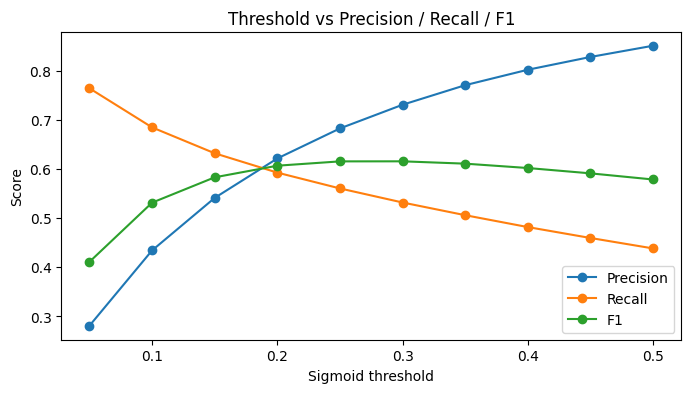

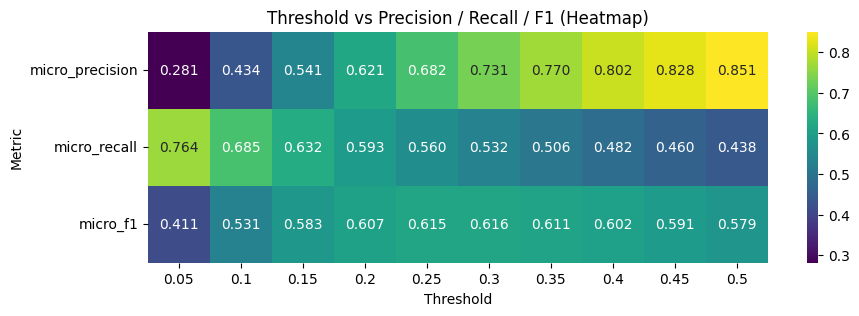

In [ ]:
import seaborn as sns
# --- Line plot ---
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["micro_precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["micro_recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["micro_f1"], marker="o", label="F1")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")
plt.legend()
plt.show()

# --- Heatmap ---
heatmap_data = threshold_df.set_index("threshold")[["micro_precision", "micro_recall", "micro_f1"]].T

plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Threshold vs Precision / Recall / F1 (Heatmap)")
plt.show()

In [ ]:
import os

output_path = "/content/drive/MyDrive/langF1(XLMR-CYCLIC)M-T-M.csv"
per_lang_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to /content/drive/MyDrive/langF1(MBERT)M-T-M.csv


In [ ]:
### Label-wise F1 Analysis (Transformer Only)

from sklearn.metrics import precision_score, recall_score, f1_score

transformer_label_f1 = f1_score(
    test_labels, transformer_pred, average=None, zero_division=0
)
transformer_label_precision = precision_score(
    test_labels, transformer_pred, average=None, zero_division=0
)
transformer_label_recall = recall_score(
    test_labels, transformer_pred, average=None, zero_division=0
)

# Create a DataFrame for label-wise transformer scores, including rarity (support)
label_analysis_df = pd.DataFrame({
    "label_index": range(NUM_LABELS),
    "transformer_precision": transformer_label_precision,
    "transformer_recall": transformer_label_recall,
    "transformer_f1": transformer_label_f1,
    "support": test_labels.sum(axis=0).astype(int)  # rarity: how many times this label appears in test set
})

# Sort by rarity (rarest labels first) — makes the imbalance story easy to read top-to-bottom
label_analysis_df = label_analysis_df.sort_values("support").reset_index(drop=True)

print(f"Label-wise F1 analysis for all {NUM_LABELS} labels (sorted by rarity, rarest first):")
display(label_analysis_df.round(4))

# Save full table to Drive
output_path = "/content/drive/MyDrive/XLMR-CYCLIC-MTM-label_wise_f1_analysis.csv"
label_analysis_df.to_csv(output_path, index=False)
print(f"\nSaved to {output_path}")

Label-wise F1 analysis for all 567 labels (sorted by rarity, rarest first):


,label_index,transformer_precision,transformer_recall,transformer_f1,support
0,20,0.0000,0.0000,0.0000,0
1,2,0.0000,0.0000,0.0000,0
2,341,0.0000,0.0000,0.0000,0
3,343,0.0000,0.0000,0.0000,0
4,340,0.0000,0.0000,0.0000,0
...,...,...,...,...,...
562,505,0.9510,0.8593,0.9028,1016
563,126,0.9316,0.5756,0.7116,1018
564,479,0.9160,0.7896,0.8481,1036
565,115,0.9585,0.2963,0.4527,1090



Saved to /content/drive/MyDrive/Mbert-MTM-label_wise_f1_analysis.csv
